# Fase 0 -- Motor de horizonte + Bech

Radar Siting Toolkit -- ver `Plan_Tecnico_Radar_Siting_Toolkit.md`, secciones 3 y 9.

Este notebook es la ruta critica del informe: implementa y valida el motor
(angulo de horizonte acumulado + bloqueo parcial de haz de Bech et al. 2003)
de forma independiente del empaquetado como plugin QGIS.

**Contenido:**
1. Motor sobre un DEM sintetico (una cresta conocida), para poder verificar
   contra un resultado esperado a mano -- no hay DEM real de Jamaica ni
   coordenadas de sitios candidatos cargadas todavia (ver seccion final).
2. Validacion Nivel 2 (seccion 7): `core.blockage` contra `wradlib.qual`,
   celda a celda, sobre el mismo perfil.
3. Manejo de nodata (seccion 3.5): demostracion de que una celda sin dato
   nunca se propaga como visibilidad ficticia.
4. Que falta para el analisis real de Jamaica (Fase 0 completa).


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.io import MemoryFile
from rasterio.transform import Affine

from core.geometry import aeqd_proj4, ray_points, transformer_from_aeqd
from core.dem import Dem, DemNodataError
from core.horizon import horizon_angle, min_visible_height
from core.blockage import beam_height, half_power_radius, beam_block_frac, cum_beam_block_frac

np.set_printoptions(precision=3, suppress=True)


## 1. DEM sintetico

Radar ilustrativo cerca de las Blue Mountains, Jamaica (**coordenadas de
ejemplo, terreno sintetico -- no es un candidato real**). Rejilla de 30 m
(resolucion nativa GLO-30) de 20 km x 20 km en el propio plano AEQD
centrado en el radar, con:

- una cresta recta de 700 m a 6 km de rango, que debe producir sombra
  detras;
- una loma suave de fondo;
- una franja sin dato (nodata) en un azimut, para la prueba de la seccion 3.


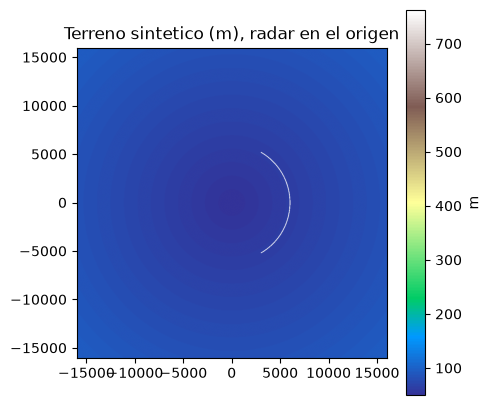

In [2]:
lon0, lat0 = -76.65, 18.05  # ilustrativo, no un candidato real

res = 30.0
half_extent = 16_000.0
n = int(2 * half_extent / res)
transform = Affine(res, 0.0, -half_extent, 0.0, -res, half_extent)
crs = aeqd_proj4(lon0, lat0)

xs = -half_extent + res * (np.arange(n) + 0.5)
ys = half_extent - res * (np.arange(n) + 0.5)
X, Y = np.meshgrid(xs, ys)
R = np.hypot(X, Y)
AZ = (np.degrees(np.arctan2(X, Y))) % 360.0

terrain = 50.0 + 0.002 * R  # loma suave de fondo

ridge_range = 6000.0
ridge_width = 80.0
ridge_height = 700.0
in_ridge_band = np.abs(R - ridge_range) < (ridge_width / 2.0)
ridge_azimuth_span = (AZ > 30) & (AZ < 150)  # cresta que cruza un sector, no los 360 grados
terrain = np.where(in_ridge_band & ridge_azimuth_span, terrain + ridge_height, terrain)

nodata_value = -9999.0
nodata_mask = (AZ > 200) & (AZ < 210) & (R > 3000) & (R < 4000)
terrain_with_nodata = np.where(nodata_mask, nodata_value, terrain)

profile = dict(
    driver="GTiff", height=n, width=n, count=1, dtype="float32",
    crs=crs, transform=transform, nodata=nodata_value,
)

memfile = MemoryFile()
with memfile.open(**profile) as dst:
    dst.write(terrain_with_nodata.astype("float32"), 1)

dem_path = "/vsimem/synthetic_dem.tif"
with rasterio.open(dem_path, "w", **profile) as dst:
    dst.write(terrain_with_nodata.astype("float32"), 1)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(terrain, extent=[-half_extent, half_extent, -half_extent, half_extent], cmap="terrain")
ax.set_title("Terreno sintetico (m), radar en el origen")
plt.colorbar(im, ax=ax, label="m")
plt.show()


## 2. Motor: horizonte acumulado y bloqueo parcial

Radar: altura de antena `h0` = elevacion del terreno en el origen + 20 m de
torre. Barrido en 360 azimutes cada 2 grados, muestreo a resolucion nativa
del DEM (30 m), alcance 15 km. Escaneo mas bajo a 0.5 grados de elevacion,
ancho de haz 1.0 grados (valores tipicos de un radar meteorologico banda C).


In [3]:
dem = Dem(dem_path, vertical_datum="synthetic, arbitrary")

ground_at_radar = dem.sample_lonlat([lon0], [lat0], nodata_policy="raise")[0]
tower_height = 20.0
h0 = ground_at_radar + tower_height
k = 4.0 / 3.0
elevation_deg = 0.5
beamwidth_deg = 1.0
max_range_m = 15_000.0

to_lonlat = transformer_from_aeqd(lon0, lat0)

azimuths = np.arange(0, 360, 2.0)
theta_grid = []
hmin_grid = []
cbb_grid = []
s_ref = None

for az in azimuths:
    s, x, y = ray_points(az, max_range_m, res)
    s_ref = s
    lons, lats = to_lonlat.transform(x, y)
    z = dem.sample_lonlat(lons, lats, nodata_policy="block")

    theta = horizon_angle(z, s, h0, k)
    hmin = min_visible_height(z, s, h0, k, theta=theta)

    bh = beam_height(s, h0, np.deg2rad(elevation_deg), k)
    a = half_power_radius(s, np.deg2rad(beamwidth_deg))
    pbb = beam_block_frac(z - bh, a)
    cbb = cum_beam_block_frac(pbb)

    theta_grid.append(theta)
    hmin_grid.append(hmin)
    cbb_grid.append(cbb)

theta_grid = np.array(theta_grid)
hmin_grid = np.array(hmin_grid)
cbb_grid = np.array(cbb_grid)

print("h0 =", h0, "m  |  ground at radar =", ground_at_radar, "m")
print("theta_grid shape (azimuths, ranges):", theta_grid.shape)


h0 = 70.01414108276367 m  |  ground at radar = 50.01414108276367 m
theta_grid shape (azimuths, ranges): (180, 500)


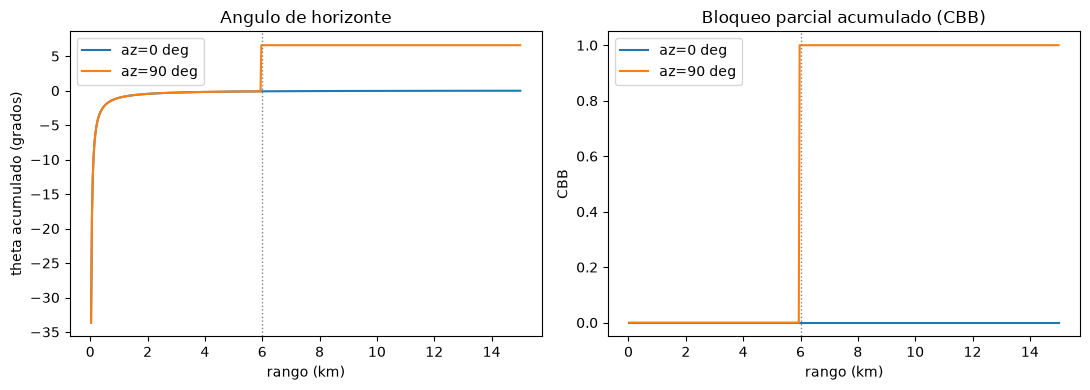

OK: theta y CBB son monotonos no decrecientes en cada rayo.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

az_examples = [0, 90]  # 90 deg cruza la cresta; 0 deg no
for az in az_examples:
    idx = np.argmin(np.abs(azimuths - az))
    axes[0].plot(s_ref / 1000.0, np.degrees(theta_grid[idx]), label=f"az={az} deg")
axes[0].set_xlabel("rango (km)")
axes[0].set_ylabel("theta acumulado (grados)")
axes[0].set_title("Angulo de horizonte")
axes[0].legend()
axes[0].axvline(6.0, color="grey", ls=":", lw=1)

for az in az_examples:
    idx = np.argmin(np.abs(azimuths - az))
    axes[1].plot(s_ref / 1000.0, cbb_grid[idx], label=f"az={az} deg")
axes[1].set_xlabel("rango (km)")
axes[1].set_ylabel("CBB")
axes[1].set_title("Bloqueo parcial acumulado (CBB)")
axes[1].legend()
axes[1].axvline(6.0, color="grey", ls=":", lw=1)
plt.tight_layout()
plt.show()

assert np.all(np.diff(theta_grid, axis=1) >= -1e-9), "theta debe ser no decreciente por rayo"
assert np.all(np.diff(cbb_grid, axis=1) >= -1e-9), "CBB debe ser no decreciente por rayo (obligatorio, seccion 3.2)"
print("OK: theta y CBB son monotonos no decrecientes en cada rayo.")


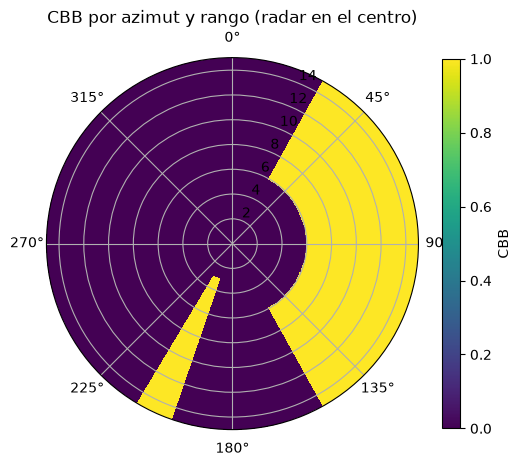

In [5]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
theta_rad = np.deg2rad(azimuths)
R_mesh, T_mesh = np.meshgrid(s_ref / 1000.0, theta_rad)
mesh = ax.pcolormesh(T_mesh, R_mesh, cbb_grid, cmap="viridis", vmin=0, vmax=1, shading="auto")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("CBB por azimut y rango (radar en el centro)")
plt.colorbar(mesh, ax=ax, label="CBB", shrink=0.8)
plt.show()


La sombra de la cresta (30-150 grados, ~6 km) aparece como un sector de CBB
alto que persiste hasta el borde del dominio -- exactamente el efecto que
justifica publicar CBB y no PBB por bin (seccion 3.2).


## 3. Validacion Nivel 2 -- contra wradlib

Seccion 7: mismo perfil `(terreno, altura de haz, radio de haz)`, comparado
celda a celda contra `wradlib.qual.beam_block_frac` /
`wradlib.qual.cum_beam_block_frac`. No valida la fisica de Bech (eso ya esta
en el paper); valida que nuestra reimplementacion en numpy puro (sin
wradlib como dependencia de runtime, seccion 3.3) es aritmeticamente
identica.


max |PBB_ours - PBB_wradlib| = 0.000e+00
max |CBB_ours - CBB_wradlib| = 0.000e+00
OK: identico a wradlib dentro de 1e-9.


/home/node/workspace/radar-siting-toolkit/.venv/lib/python3.11/site-packages/wradlib/qual.py:184: RuntimeWarning: invalid value encountered in sqrt
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)
/home/node/workspace/radar-siting-toolkit/.venv/lib/python3.11/site-packages/wradlib/qual.py:184: RuntimeWarning: invalid value encountered in arcsin
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)


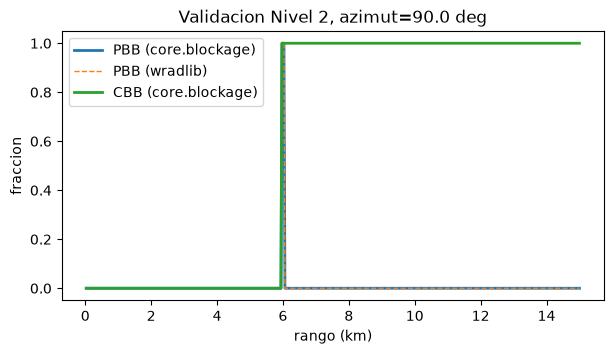

In [6]:
import wradlib

az = 90.0  # cruza la cresta
s, x, y = ray_points(az, max_range_m, res)
lons, lats = to_lonlat.transform(x, y)
z = dem.sample_lonlat(lons, lats, nodata_policy="block")

bh = beam_height(s, h0, np.deg2rad(elevation_deg), k)
a = half_power_radius(s, np.deg2rad(beamwidth_deg))

pbb_ours = beam_block_frac(z - bh, a)
pbb_wradlib = wradlib.qual.beam_block_frac(z, bh, a)

cbb_ours = cum_beam_block_frac(pbb_ours)
cbb_wradlib = wradlib.qual.cum_beam_block_frac(pbb_wradlib[np.newaxis, :])[0]

max_diff_pbb = np.nanmax(np.abs(pbb_ours - pbb_wradlib))
max_diff_cbb = np.nanmax(np.abs(cbb_ours - cbb_wradlib))
print(f"max |PBB_ours - PBB_wradlib| = {max_diff_pbb:.3e}")
print(f"max |CBB_ours - CBB_wradlib| = {max_diff_cbb:.3e}")

np.testing.assert_allclose(pbb_ours, pbb_wradlib, atol=1e-9)
np.testing.assert_allclose(cbb_ours, cbb_wradlib, atol=1e-9)
print("OK: identico a wradlib dentro de 1e-9.")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(s / 1000.0, pbb_ours, label="PBB (core.blockage)", lw=2)
ax.plot(s / 1000.0, pbb_wradlib, label="PBB (wradlib)", lw=1, ls="--")
ax.plot(s / 1000.0, cbb_ours, label="CBB (core.blockage)", lw=2)
ax.set_xlabel("rango (km)")
ax.set_ylabel("fraccion")
ax.set_title(f"Validacion Nivel 2, azimut={az} deg")
ax.legend()
plt.show()


## 4. Nodata: bloqueante o fallo ruidoso, nunca silencioso

Seccion 3.5: el rayo a 205 grados cruza la franja sin dato inyectada en el
DEM sintetico. Con la politica por defecto (`raise`) el motor debe fallar de
forma explicita, no devolver 0 o NaN silencioso.


In [7]:
az_through_nodata = 205.0
s, x, y = ray_points(az_through_nodata, max_range_m, res)
lons, lats = to_lonlat.transform(x, y)

try:
    z = dem.sample_lonlat(lons, lats, nodata_policy="raise")
    raise AssertionError("se esperaba DemNodataError y no ocurrio")
except DemNodataError as e:
    print("Fallo ruidoso, como se espera:")
    print(" ", e)

z_blocked = dem.sample_lonlat(lons, lats, nodata_policy="block")
n_blocked = np.isinf(z_blocked).sum()
print(f"\nCon nodata_policy='block': {n_blocked} celda(s) tratadas como terreno bloqueante (+inf),"
      " nunca 0 ni NaN silencioso.")


Fallo ruidoso, como se espera:
  33 sampled point(s) hit nodata in /vsimem/synthetic_dem.tif. Fill or clip the DEM, or pass nodata_policy='block' to treat these cells as fully blocking terrain.

Con nodata_policy='block': 33 celda(s) tratadas como terreno bloqueante (+inf), nunca 0 ni NaN silencioso.


## 5. Que falta para el analisis real de Jamaica

Este notebook valida el motor (horizonte + Bech) matematicamente y contra
wradlib, sobre terreno sintetico. **No es todavia el analisis de Jamaica**
que pide la seccion 9 como entregable de Fase 0. Para eso hace falta, del
equipo de mision:

1. DEM real de la zona de interes -- GLO-30 (y, si se resuelve la licencia
   no-comercial, FABDEM) recortado al area de analisis, seccion 5.
2. Coordenadas y alturas de torre de los sitios candidatos (y de radares
   existentes, propios o extranjeros, si el modo Red aplica).
3. Capa de importancia (poblacion + cuencas de respuesta rapida como minimo
   defendible, seccion 4.3) -- pendiente de definir con MSJ (riesgo
   identificado en seccion 10).
4. Confirmacion de parametros de barrido: ancho de haz y elevaciones reales
   del radar considerado (aqui se usaron 1.0 grados / 0.5 grados como
   valores tipicos de banda C, no un radar especifico).

Con eso, este mismo motor (`core.geometry`, `core.dem`, `core.horizon`,
`core.blockage`) corre directamente sobre datos reales; no hace falta
cambiar nada del codigo, solo las entradas.
